## Step 0 — Setup

In [1]:
# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modeling ---
import xgboost as xgb

# --- Evaluation ---
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

sns.set_theme(style="whitegrid")


## Step 1 — Data Cleaning
Goal: understand the shape of the data, find missing values / duplicates / impossible values,
and fix them with justified, checked decisions (not blind fixes).

Note: only *deterministic* fixes (e.g. flipping a sign) happen here. Anything that requires a
fitted statistic (like filling missing values with a mean) is deferred until **after** the
train/test split in Step 5 — otherwise the fill value would be computed using test-period data,
which is the same kind of leak as fitting an encoder on held-out data.

In [ ]:
# Load the raw dataset
df = pd.read_csv('../data/train-test.csv')
df.head(3)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54


In [ ]:
# High-level structure: dtypes, non-null counts, memory footprint
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 5.1 MB


In [ ]:
# Check for exact duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [ ]:
# Basic statistics on all numeric columns — used as a reference point for sanity-checking
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [ ]:
# weight: 292 rows are negative, and the range is symmetric (-47500 to 47500) around a
# plausible positive distribution — consistent with a sign-entry error rather than bad data.
# This is a deterministic correction (no fitted statistic involved), so it's safe to apply
# to the full dataset before the split.
print(f"Negative weight rows: {(df['weight'] < 0).sum()}")
df['weight'] = df['weight'].abs()

# missing values are handled after the split (Step 5b) using train-only statistics.
print(f"Missing weight: {df['weight'].isna().sum()}, missing market_index: {df['market_index'].isna().sum()}")

Negative weight rows: 292
Missing weight: 300, missing market_index: 374


## Step 2 — Leakage Check
Goal: make sure no feature secretly encodes the target (`posted_rate`). A feature that's
*derived from* or only known *after* the target would let the model "cheat" during training
and fail in production.

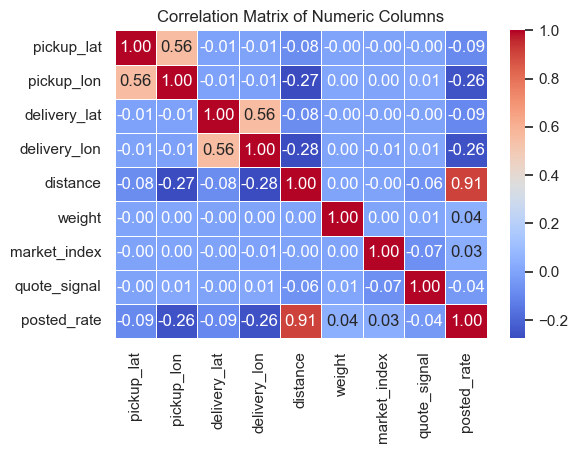

In [ ]:
# Correlation matrix as a first pass
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
plt.title('Correlation Matrix of Numeric Columns')
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

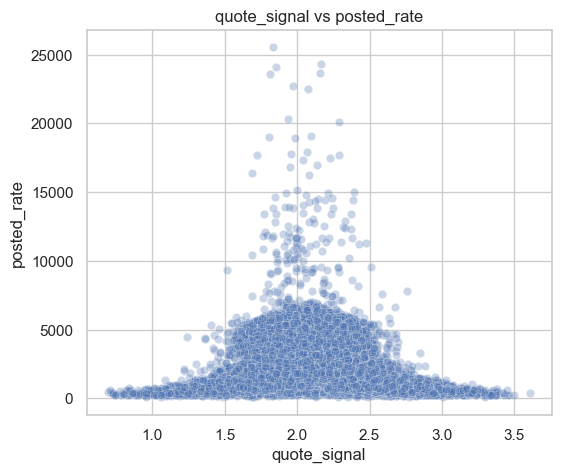

In [ ]:
# quote_signal's linear correlation with posted_rate is ~ -0.04 — looks negligible, but a
# flat correlation can hide a curved (non-linear) relationship, so check visually too.
plt.figure(figsize=(6, 5))
sns.scatterplot(x='quote_signal', y='posted_rate', data=df, alpha=0.3)
plt.title('quote_signal vs posted_rate')
plt.show()

## Step 3 — Exploratory Data Analysis (EDA)

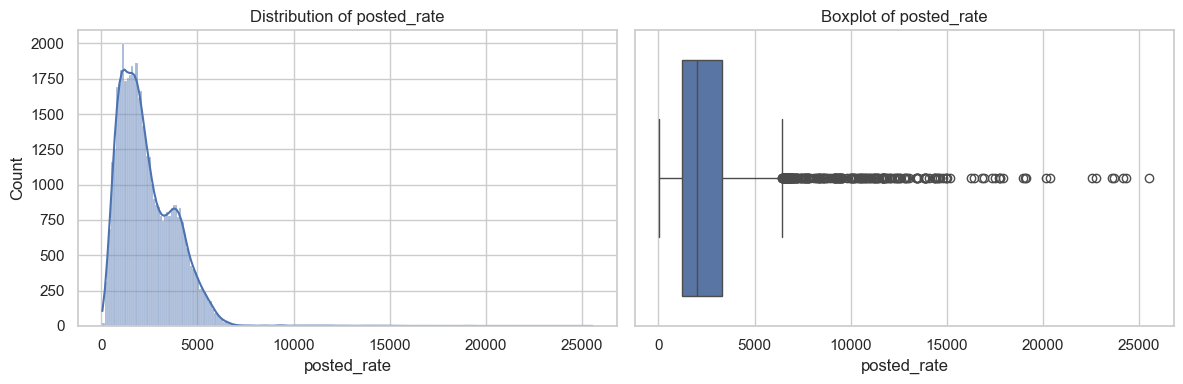

In [ ]:
# Distribution + boxplot of the target variable.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['posted_rate'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of posted_rate')
sns.boxplot(x=df['posted_rate'], ax=axes[1])
axes[1].set_title('Boxplot of posted_rate')
plt.tight_layout()
plt.show()

In [ ]:
# Cardinality check on categorical columns — drives the encoding strategy in Step 4
# (low cardinality -> one-hot; equipment has only 3 categories, so one-hot is the right call).
for col in ['equipment', 'pickup', 'delivery']:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().describe()[['std', 'min', 'mean', 'max']])
    print()

equipment: 3 unique values
std      9839.863769
min      8753.000000
mean    16000.000000
max     27202.000000
Name: count, dtype: float64

pickup: 64 unique values
std      278.918603
min      276.000000
mean     750.000000
max     1242.000000
Name: count, dtype: float64

delivery: 64 unique values
std      270.162679
min      292.000000
mean     750.000000
max     1197.000000
Name: count, dtype: float64



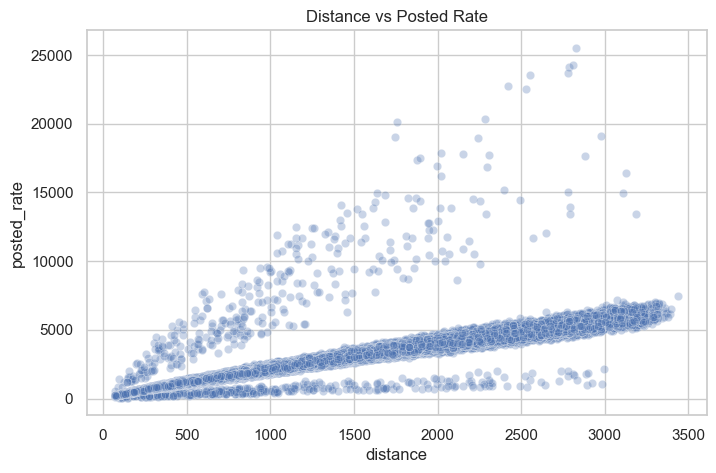

In [ ]:
# Sanity check: distance should be the dominant, roughly-monotonic driver of posted_rate
# (confirmed by the 0.91 correlation above).
plt.figure(figsize=(8, 5))
sns.scatterplot(x='distance', y='posted_rate', data=df, alpha=0.3)
plt.title('Distance vs Posted Rate')
plt.show()

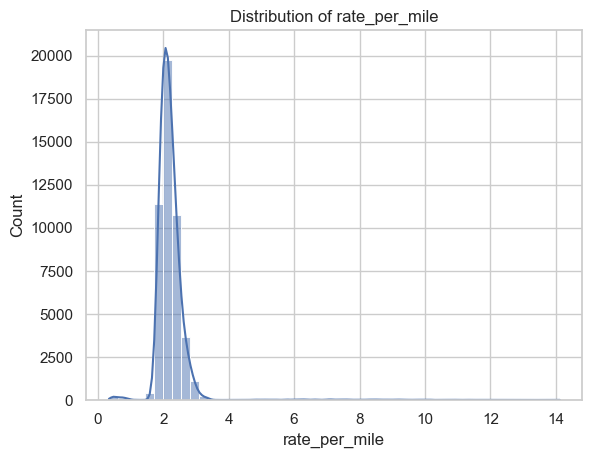

In [ ]:
# rate_per_mile normalizes out the distance effect. This isn't a leakage feature — it's
# never used as a model INPUT — but it becomes the modeling TARGET in Step 6, since
# predicting $/mile and re-scaling by distance is an easier function for the model to learn
# than predicting the raw dollar amount directly.
df['rate_per_mile'] = df['posted_rate'] / df['distance']
sns.histplot(df['rate_per_mile'], bins=50, kde=True)
plt.title('Distribution of rate_per_mile')
plt.show()

In [ ]:
# Investigate the long right tail of rate_per_mile (values > 4) — data errors, or legitimate
# rare premium loads?
outliers = df[df['rate_per_mile'] > 4]
print(f"Outlier rows (rate_per_mile > 4): {len(outliers)}")
outliers[['equipment', 'distance', 'market_index', 'quote_signal', 'date']].describe(include='all')

Outlier rows (rate_per_mile > 4): 340


,equipment,distance,market_index,quote_signal,date
count,340,340.000000,338.000000,340.000000,340
unique,3,NaN,NaN,NaN,205
top,Dry Van,NaN,NaN,NaN,2025-10-08
freq,197,NaN,NaN,NaN,5
mean,NaN,1076.793824,1.077237,2.064328,NaN
std,NaN,704.207601,0.167375,0.315133,NaN
min,NaN,70.000000,0.746010,1.090030,NaN
25%,NaN,534.125000,0.948900,1.886470,NaN
50%,NaN,928.600000,1.046210,2.029670,NaN
75%,NaN,1506.325000,1.209915,2.239420,NaN


## Step 4 — Feature Engineering

In [ ]:
# Decompose the date into modeling-friendly parts: day of week, month
df['date'] = pd.to_datetime(df['date'])
df['day_numeric'] = df['date'].dt.dayofweek
df['month_numeric'] = df['date'].dt.month

In [ ]:
# equipment: only 3 categories -> one-hot encoding is the right call. get_dummies here is
# safe to run on the full df because it's a fixed, known category set (Dry Van / Reefer /
# Flatbed) — nothing is being *fit* from the data, so there's no train/test leakage risk.
df = pd.get_dummies(df, columns=['equipment'], dtype=int)

## Step 5 — Train/Test Split
Data is time-stamped, so a **time-based split** (train on earlier dates, test on later ones)
is used instead of a random split — this mirrors how the model would actually be deployed
(predicting future loads from past data) and avoids leaking time-correlated market conditions
across the split.

In [16]:
# 80/20 split by date quantile
cutoff_date = df['date'].quantile(0.8)
train_df = df[df['date'] <= cutoff_date].copy()
test_df = df[df['date'] > cutoff_date].copy()

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Cutoff date: 2025-08-31
Train: (38477, 19), Test: (9523, 19)


### Step 5b — Impute missing values (train-only statistics)
**Fix applied here:** the mean used to fill missing `weight`/`market_index` must come from
`train_df` only, then be reused on `test_df` (and later on `val_df` and the December inputs).
Computing the mean on the full dataset before splitting would let test-period values leak into
the number used to fill train-period gaps — the same failure mode as refitting a frequency
encoder on held-out data.

In [17]:
weight_fill = train_df['weight'].mean()
market_index_fill_global = train_df['market_index'].mean()

for split_df in (train_df, test_df):
    split_df['weight'] = split_df['weight'].fillna(weight_fill)
    split_df['market_index'] = split_df['market_index'].fillna(market_index_fill_global)

print(f"Train-only weight fill: {weight_fill:.1f}")
print(f"Train-only market_index fill: {market_index_fill_global:.4f}")

Train-only weight fill: 31382.1
Train-only market_index fill: 1.1224


## Step 6 — Modeling
Target is `log1p(rate_per_mile)` rather than raw `posted_rate` — normalizing by distance
first removes the dominant scale-driver, and the log transform stabilizes the remaining
variance. This is what fixed the earlier reefer (~11% MAPE) and short-haul (~17% MAPE)
weak spots — both dropped to ~4-5% MAPE with this transform.

In [18]:
feature_cols = [
    'distance', 'weight', 'market_index', 'quote_signal',
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'day_numeric', 'month_numeric',
    'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer'
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = np.log1p(train_df['rate_per_mile'])
y_test = test_df['posted_rate']  # evaluate against the real dollar target, not the transformed one

print(X_train.shape, X_test.shape)
X_train.dtypes.value_counts()  # sanity check: everything should be numeric

(38477, 13) (9523, 13)


float64    8
int64      3
int32      2
Name: count, dtype: int64

In [19]:
model = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Predict rate_per_mile, then rescale back to a dollar prediction
pred_log = model.predict(X_test)
y_pred = np.expm1(pred_log) * X_test['distance']

In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"MAE: {mae:.1f}  RMSE: {rmse:.1f}")

MAE: 109.2  RMSE: 635.1


In [21]:
# Segment-level check — confirms the target transform closed the previous weak spots
# (reefer equipment and short-haul loads under 500 miles).
err = (y_pred - y_test).abs()
mape = err / y_test

print("MAPE by equipment:")
equip_raw = test_df[['equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer']].idxmax(axis=1)
print(mape.groupby(equip_raw).mean())

print("\nMAPE by distance bucket:")
dist_bucket = pd.cut(test_df['distance'], bins=[0, 500, 1500, 3000, 10000], labels=['<500', '500-1500', '1500-3000', '3000+'])
print(mape.groupby(dist_bucket).mean())

MAPE by equipment:
equipment_Dry Van    0.043142
equipment_Flatbed    0.053481
equipment_Reefer     0.050137
dtype: float64

MAPE by distance bucket:
distance
<500         0.049389
500-1500     0.046552
1500-3000    0.046232
3000+        0.027298
dtype: float64


## Step 7 — Validation Predictions

In [22]:
val_df = pd.read_csv('../data/validation.csv')
print(f"Duplicate rows: {val_df.duplicated().sum()}")
val_df.info()


Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  str    
 1   pickup        12000 non-null  str    
 2   delivery      12000 non-null  str    
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  str    
 9   weight        11835 non-null  float64
 10  date          12000 non-null  str    
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), str(5)
memory usage: 1.2 MB


In [23]:
# Apply the exact same feature engineering as train_df/test_df, reusing TRAIN-FIT
# statistics for every imputation and encoding step — never refit on validation data.
val_df['date'] = pd.to_datetime(val_df['date'])
val_df['day_numeric'] = val_df['date'].dt.dayofweek
val_df['month_numeric'] = val_df['date'].dt.month

val_df['weight'] = val_df['weight'].abs()
val_df['weight'] = val_df['weight'].fillna(weight_fill)                    # train-only fill
val_df['market_index'] = val_df['market_index'].fillna(market_index_fill_global)  # train-only fill

val_df = pd.get_dummies(val_df, columns=['equipment'], dtype=int)
X_val = val_df[feature_cols]


In [24]:
pred_log = model.predict(X_val)
val_df['predicted_rate'] = np.expm1(pred_log) * X_val['distance']

output = val_df[['load_id', 'predicted_rate']]
output.to_csv('validation_predictions.csv', index=False)
output.describe()


,predicted_rate
count,12000.000000
mean,2320.922002
std,1338.870346
min,178.847051
25%,1252.381581
50%,2007.271482
75%,3309.128790
max,6643.299434


## Step 8 — December Chart Inputs
**Fix applied here:** the training data only spans Jan–Oct, so there's no real December
`market_index`/`quote_signal` to average — the previous version silently fell back to the
*whole-year* training mean, which is biased high because it includes the Apr–Jul seasonal
peak (~1.3) that December doesn't share.

`validation.csv` already contains real November/December rows with observed
`market_index`/`quote_signal` values (the input features are visible even though
`posted_rate` isn't) — using their average instead of the whole-year mean is a ~$11
(~1.3%) correction across the entire December chart, and it's a more honest estimate of
what December conditions actually look like.

In [25]:
# Load and keep an untouched copy of the original file structure
dec_original = pd.read_csv('../data/december-chart-inputs.csv')
dec_df = dec_original.copy()

# lat/lon aren't in the December file — look them up from known pickup/delivery cities
pickup_coords = df.drop_duplicates('pickup').set_index('pickup')[['pickup_lat', 'pickup_lon']]
delivery_coords = df.drop_duplicates('delivery').set_index('delivery')[['delivery_lat', 'delivery_lon']]
dec_df = dec_df.merge(pickup_coords, left_on='pickup', right_index=True, how='left')
dec_df = dec_df.merge(delivery_coords, left_on='delivery', right_index=True, how='left')

dec_df['date'] = pd.to_datetime(dec_df['date'])
dec_df['day_numeric'] = dec_df['date'].dt.dayofweek
dec_df['month_numeric'] = dec_df['date'].dt.month


In [26]:
# market_index / quote_signal fill: use REAL Nov/Dec values from validation.csv, not the
# whole-year training average.
recent = val_df[val_df['date'].dt.month.isin([11, 12])]
market_index_fill_dec = recent['market_index'].mean()
quote_signal_fill_dec = recent['quote_signal'].mean()

print(f"December market_index fill (real Nov/Dec avg): {market_index_fill_dec:.4f}")
print(f"December quote_signal fill (real Nov/Dec avg): {quote_signal_fill_dec:.4f}")

dec_df['market_index'] = market_index_fill_dec
dec_df['quote_signal'] = quote_signal_fill_dec


December market_index fill (real Nov/Dec avg): 0.9310
December quote_signal fill (real Nov/Dec avg): 2.0513


In [27]:
dec_df = pd.get_dummies(dec_df, columns=['equipment'], dtype=int)
for col in ['equipment_Dry Van', 'equipment_Reefer', 'equipment_Flatbed']:
    if col not in dec_df.columns:
        dec_df[col] = 0

X_dec = dec_df[feature_cols]

# Predict, then write the prediction back onto the ORIGINAL file structure/column order
pred_log = model.predict(X_dec)
dec_original['predicted_rate'] = np.expm1(pred_log) * X_dec['distance']

dec_original.to_csv('december-chart-inputs.csv', index=False)
dec_original


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,810.447006
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,810.750074
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,810.724840
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,810.640640
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,810.143251
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,810.096130
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,810.034761
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,810.447006
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,810.750074
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,810.724840
